In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [15]:
df = pd.read_csv("Medical insurance mini project regression.csv")

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df.shape

(1338, 7)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [19]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [20]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df = df.drop_duplicates()

In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [24]:
missing_percentage = df.isnull().mean() * 100

print(missing_percentage)

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


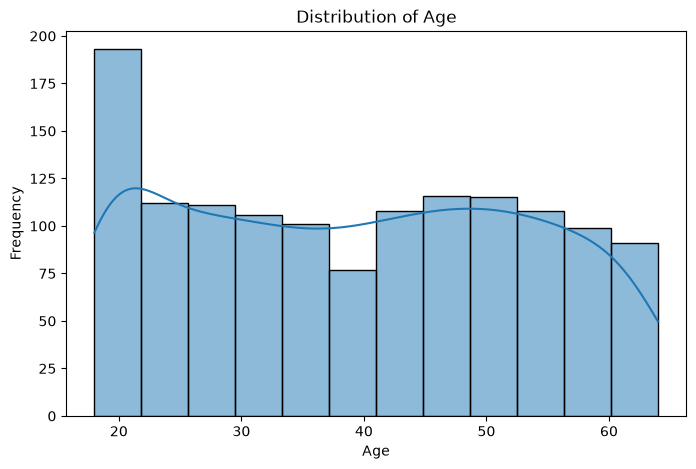

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

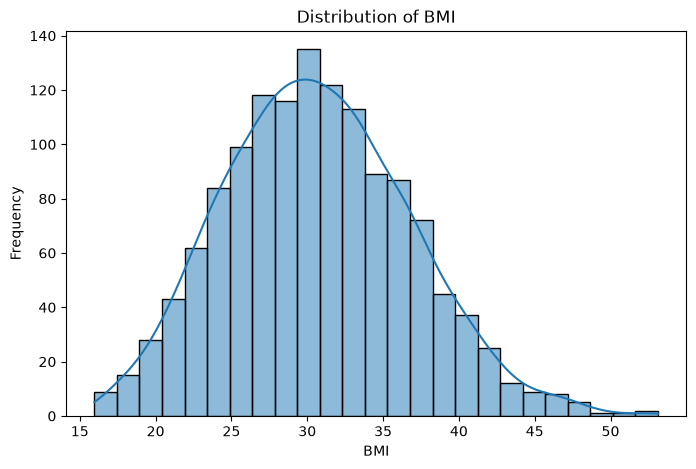

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='bmi', kde=True)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

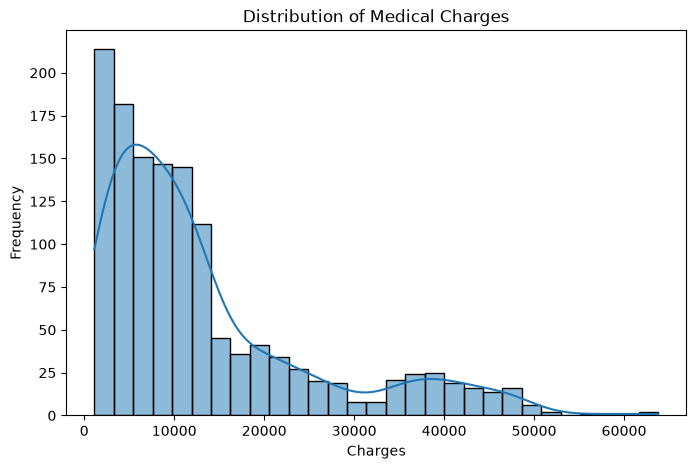

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='charges', kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

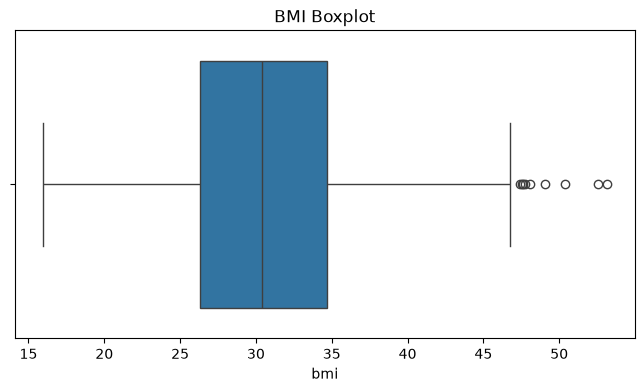

In [28]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['bmi'])

plt.title("BMI Boxplot")

plt.show()

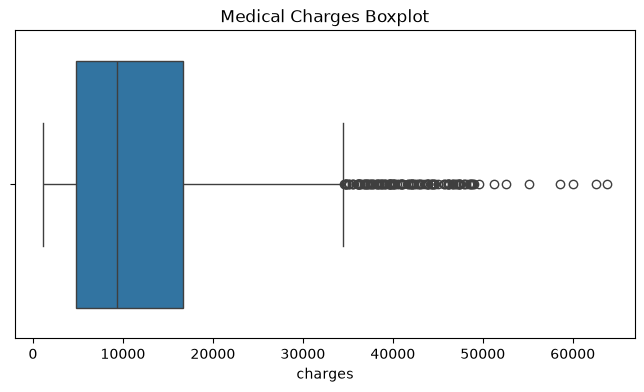

In [29]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['charges'])

plt.title("Medical Charges Boxplot")

plt.show()

In [30]:
numerical_columns = ['age', 'bmi', 'children', 'charges']

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


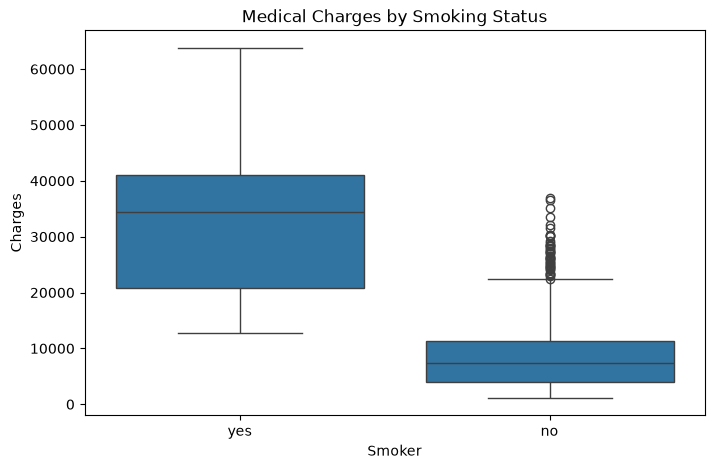

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='smoker', y='charges')

plt.title("Medical Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

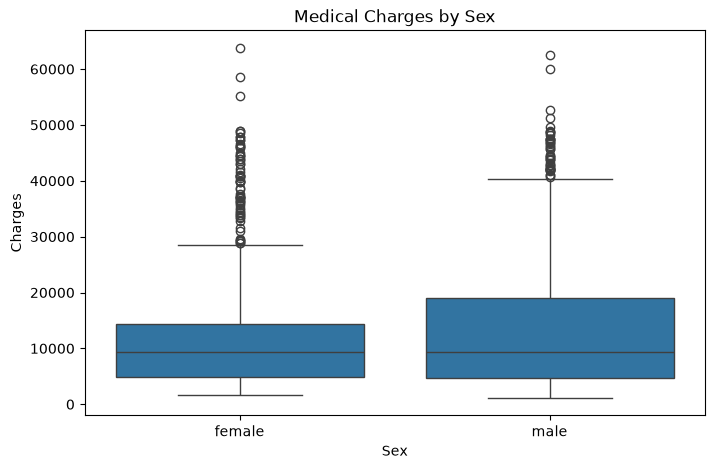

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='sex', y='charges')

plt.title("Medical Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Charges")

plt.show()

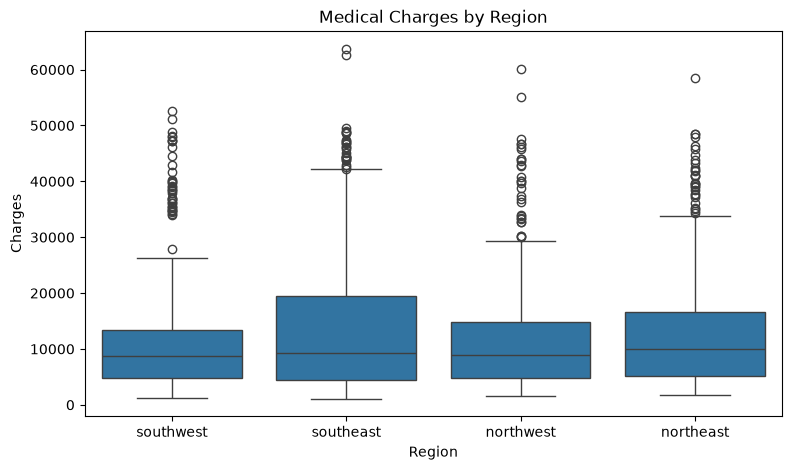

In [33]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=df, x='region', y='charges')

plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

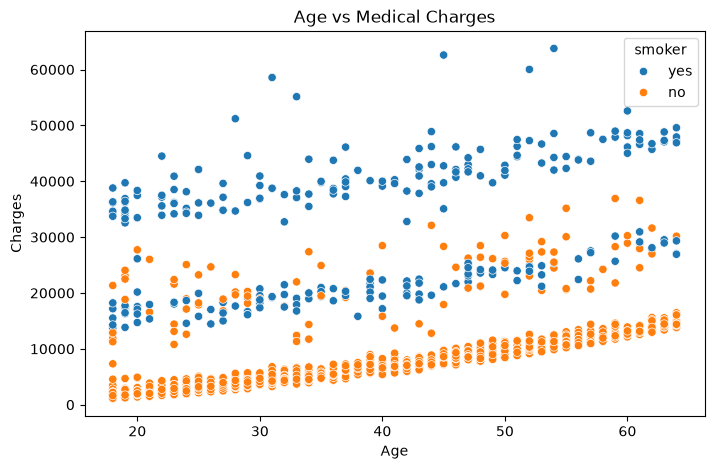

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    hue='smoker'
)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

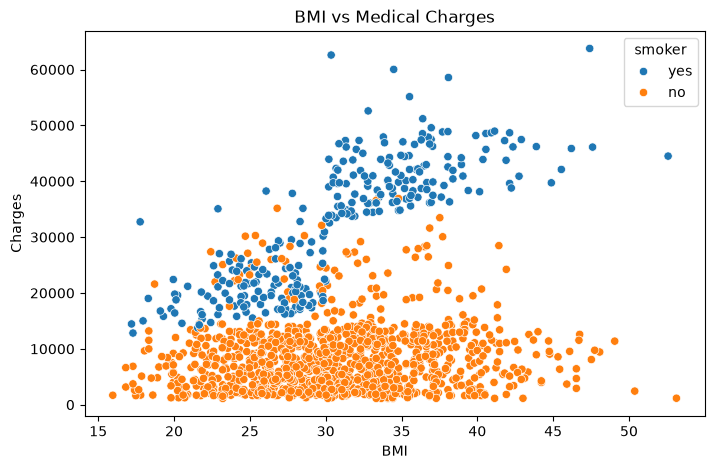

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker'
)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

In [36]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

print(correlation_matrix)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


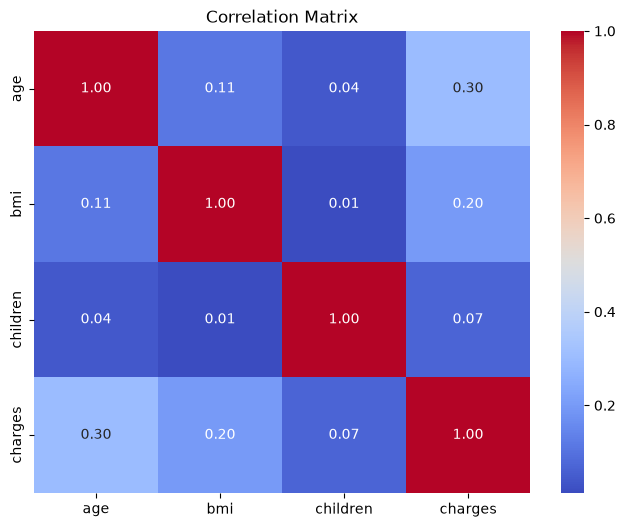

In [37]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [38]:
correlation_matrix['charges'].sort_values(ascending=False)

charges     1.000000
age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64

In [39]:
skewness = df.select_dtypes(include=np.number).skew()

print(skewness)

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64


In [40]:
X = df.drop('charges', axis=1)

y = df['charges']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [42]:
numerical_features = [
    'age',
    'bmi',
    'children'
]

categorical_features = [
    'sex',
    'smoker',
    'region'
]

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [44]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [45]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the 

In [46]:
y_train_pred = linear_model.predict(X_train)

y_test_pred = linear_model.predict(X_test)

In [47]:
mae = mean_absolute_error(y_test, y_test_pred)

print("MAE:", mae)

MAE: 4177.045561036326


In [48]:
mse = mean_squared_error(y_test, y_test_pred)

print("MSE:", mse)

MSE: 35478020.6752356


In [49]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5956.342894363587


In [50]:
r2 = r2_score(y_test, y_test_pred)

print("R²:", r2)

R²: 0.8069287081198012


In [51]:
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

In [52]:
p = len(
    linear_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

train_r2 = r2_score(
    y_train,
    linear_model.predict(X_train)
)

test_r2 = r2_score(
    y_test,
    linear_model.predict(X_test)
)

train_adj_r2 = adjusted_r2(
    train_r2,
    len(y_train),
    p
)

test_adj_r2 = adjusted_r2(
    test_r2,
    len(y_test),
    p
)

In [53]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Training metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    train_mse = mean_squared_error(y_train, train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, train_pred)

    # Testing metrics
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, test_pred)

    # Number of predictors after preprocessing
    p = len(
        model
        .named_steps['preprocessor']
        .get_feature_names_out()
    )

    # Adjusted R2
    train_adj_r2 = adjusted_r2(
        train_r2,
        len(y_train),
        p
    )

    test_adj_r2 = adjusted_r2(
        test_r2,
        len(y_test),
        p
    )

    return {
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train Adjusted R2': train_adj_r2,
        'Test Adjusted R2': test_adj_r2
    }

In [54]:
models = {}

models['Linear Regression'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [55]:
models['Decision Tree'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

In [56]:
models['Random Forest'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [57]:
models['SVR'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            SVR(
                kernel='rbf',
                C=100,
                gamma='scale',
                epsilon=0.1
            )
        )
    ]
)

In [58]:
models['KNN'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            KNeighborsRegressor(
                n_neighbors=10,
                weights='distance'
            )
        )
    ]
)

In [59]:
models['Gradient Boosting'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=2,
                random_state=42
            )
        )
    ]
)

In [60]:
models['Extra Trees'] = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            ExtraTreesRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [61]:
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    metrics = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    metrics['Model'] = model_name

    results.append(metrics)

In [62]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'Train RMSE',
        'Test RMSE',
        'Train R2',
        'Test R2',
        'Train Adjusted R2',
        'Test Adjusted R2'
    ]
]

results_df

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,0.727867,0.800965
1,Decision Tree,0.000000e+00,5904.669487,1.000000,0.810264,1.000000,0.804404
2,Random Forest,1.843325e+03,4693.433911,0.975183,0.880122,0.974995,0.876419
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,0.003503,-0.054054
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,1.000000,0.619791
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,0.867240,0.896304
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,1.000000,0.847468


In [63]:
results_df['R2 Gap'] = (
    results_df['Train R2']
    - results_df['Test R2']
)

In [64]:
results_df['Overfitting'] = np.where(
    results_df['R2 Gap'] > 0.10,
    'Y',
    'N'
)

In [65]:
comparison_table = results_df[
    [
        'Model',
        'Train RMSE',
        'Test RMSE',
        'Train R2',
        'Test R2',
        'Overfitting'
    ]
]

comparison_table.sort_values(
    by='Test RMSE'
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843325e+03,4693.433911,0.975183,0.880122,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5904.669487,1.000000,0.810264,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [66]:
best_model = models['Gradient Boosting']

best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)

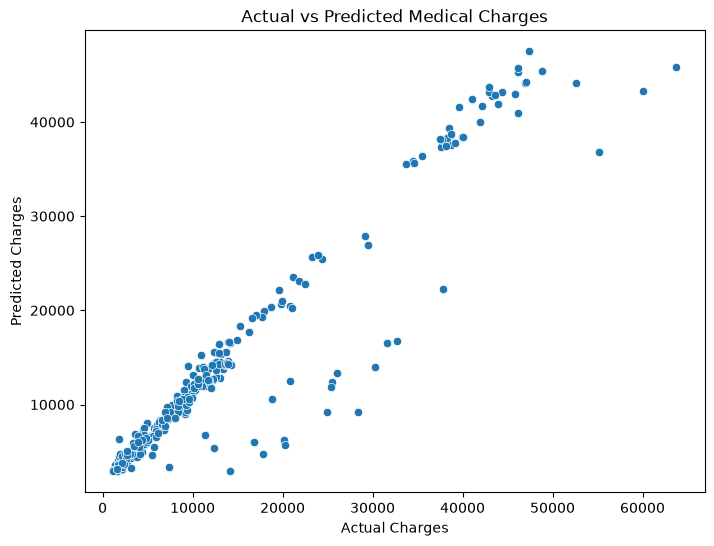

In [67]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Medical Charges")

plt.show()

In [68]:
residuals = y_test - y_test_pred

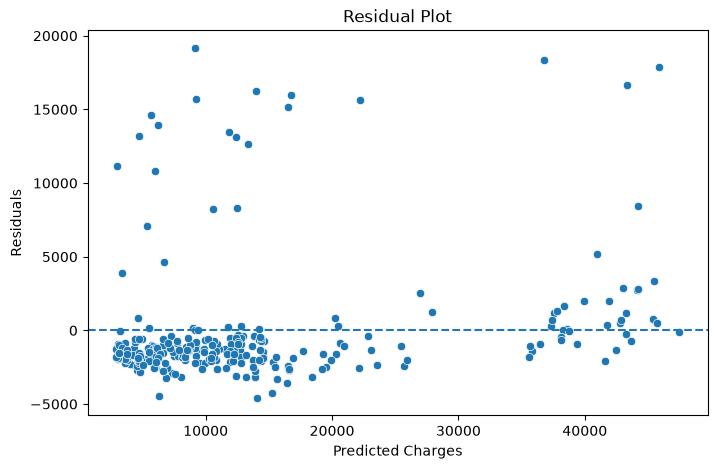

In [69]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [70]:
gb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [71]:
gb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3],
    'model__min_samples_leaf': [3, 5]
}

In [72]:
grid_search_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [73]:
grid_search_gb.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3], 'model__min_samples_leaf': [3, 5], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged::

In [74]:
print(
    "Best Parameters:",
    grid_search_gb.best_params_
)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [75]:
print(
    "Best Parameters:",
    grid_search_gb.best_params_
)

Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [76]:
best_gb_model = grid_search_gb.best_estimator_

In [77]:
tuned_gb_metrics = evaluate_model(
    best_gb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

tuned_gb_metrics

{'Train MAE': 2329.504871250882,
 'Test MAE': 2482.1426547071774,
 'Train MSE': 17771944.455306377,
 'Test MSE': 18076046.428326115,
 'Train RMSE': np.float64(4215.678409853671),
 'Test RMSE': np.float64(4251.593398753709),
 'Train R2': 0.870196930396562,
 'Test R2': 0.9016302045722792,
 'Train Adjusted R2': 0.8692172845882341,
 'Test Adjusted R2': 0.8985917552926584}

In [78]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [79]:
rf_param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt']
}

In [80]:
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [81]:
grid_search_rf.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': [1.0, 'sqrt'], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchang

In [82]:
print(
    grid_search_rf.best_params_
)

{'model__max_depth': 10, 'model__max_features': 1.0, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [83]:
best_rf_model = grid_search_rf.best_estimator_

In [84]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [85]:
voting_model = VotingRegressor(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('gb', gb_pipe)
    ]
)

In [86]:
voting_model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
estimators_ estimators_: list of regressorsThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'.,list,"[Pipeline(step...egression())]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,6
named_estimators_ named_estimators_: :class:`~sklearn.utils.Bunch`Attribute to access any fitted sub-estimators by name... versionadded:: 0.20,Bunch,{'lr': Pipeli..._state=42))])}
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'


In [87]:
voting_pred = voting_model.predict(X_test)

In [88]:
voting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        voting_pred
    )
)

voting_r2 = r2_score(
    y_test,
    voting_pred
)

print("Voting RMSE:", voting_rmse)
print("Voting R²:", voting_r2)

Voting RMSE: 4476.676745113113
Voting R²: 0.8909389206564949


In [89]:
stacking_model = StackingRegressor(
    estimators=[
        ('lr', lr_pipe),
        ('rf', rf_pipe),
        ('gb', gb_pipe)
    ],
    final_estimator=LinearRegression()
)

In [90]:
stacking_model.fit(
    X_train,
    y_train
)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",LinearRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[Pipeline(step...egression())]), Pipeline(step...m_state=42))]), Pipeline(step...m_state=42))])]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
final_estimator_ final_estimator_: estimatorThe regressor fit on the output of `estimators_` and responsible forfinal predictions.,LinearRegression,LinearRegression()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,6


In [91]:
stacking_pred = stacking_model.predict(X_test)

In [92]:
stacking_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        stacking_pred
    )
)

stacking_r2 = r2_score(
    y_test,
    stacking_pred
)

print("Stacking RMSE:", stacking_rmse)
print("Stacking R²:", stacking_r2)

Stacking RMSE: 4266.609462448814
Stacking R²: 0.9009341193715044


In [93]:
comparison_table.sort_values(
    by='Test RMSE',
    ascending=True
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843325e+03,4693.433911,0.975183,0.880122,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5904.669487,1.000000,0.810264,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [94]:
comparison_table.sort_values(
    by='Test R2',
    ascending=False
)

,Model,Train RMSE,Test RMSE,Train R2,Test R2,Overfitting
5,Gradient Boosting,4.247427e+03,4299.283701,0.868234,0.899411,N
2,Random Forest,1.843325e+03,4693.433911,0.975183,0.880122,N
6,Extra Trees,7.001328e-11,5214.299996,1.000000,0.852038,Y
1,Decision Tree,0.000000e+00,5904.669487,1.000000,0.810264,Y
0,Linear Regression,6.081107e+03,5956.342894,0.729906,0.806929,N
4,KNN,0.000000e+00,8232.400595,1.000000,0.631183,Y
3,SVR,1.163671e+04,13707.127183,0.010968,-0.022471,N


In [95]:
gb_model = (
    best_gb_model
    .named_steps['model']
)

In [96]:
feature_names = (
    best_gb_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

In [97]:
importance = gb_model.feature_importances_

In [98]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [99]:
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

In [100]:
feature_importance_df

,Feature,Importance
4,cat__smoker_yes,0.688549
1,num__bmi,0.177191
0,num__age,0.121398
2,num__children,0.011464
7,cat__region_southwest,0.000737
3,cat__sex_male,0.000334
6,cat__region_southeast,0.000194
5,cat__region_northwest,0.000134


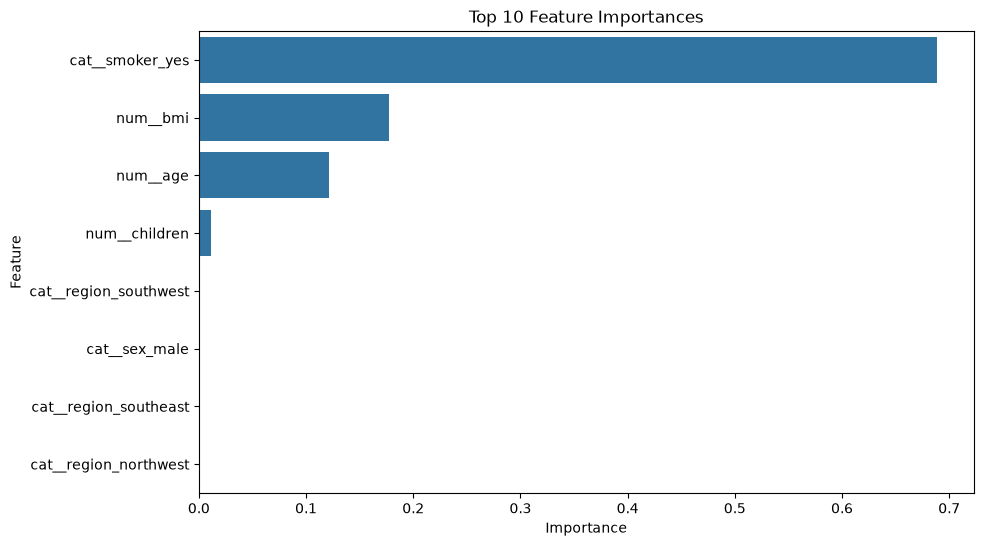

In [101]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

In [102]:
final_model = best_gb_model

In [103]:
def predict_insurance_cost(
    age,
    sex,
    bmi,
    children,
    smoker,
    region
):

    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    prediction = final_model.predict(
        input_data
    )

    return prediction[0]

In [104]:
predicted_cost = predict_insurance_cost(
    age=35,
    sex='male',
    bmi=28.5,
    children=2,
    smoker='no',
    region='northwest'
)

print(
    f"Predicted Insurance Cost: ${predicted_cost:,.2f}"
)

Predicted Insurance Cost: $7,654.81


In [105]:
import joblib

In [106]:
joblib.dump(
    final_model,
    'insurance_model.pkl'
)

['insurance_model.pkl']

In [107]:
import os

print(os.getcwd())

d:\ML_VS_Code


In [108]:
os.listdir()

['app.py',
 'insurance_model.pkl',
 'Medical insurance mini project regression.csv',
 'Mini project Supervised ML regression.ipynb',
 'myenv',
 'requirements.txt']

In [109]:
import sklearn
import joblib

print("Scikit-learn version:", sklearn.__version__)
print("Joblib version:", joblib.__version__)

Scikit-learn version: 1.9.1
Joblib version: 1.6.0
